In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /home/ubuntu/qecsim


In [3]:
from src.codes.surface_code_rotated.builder import SurfaceBuilder
from src.core.data_models import NoiseParameters


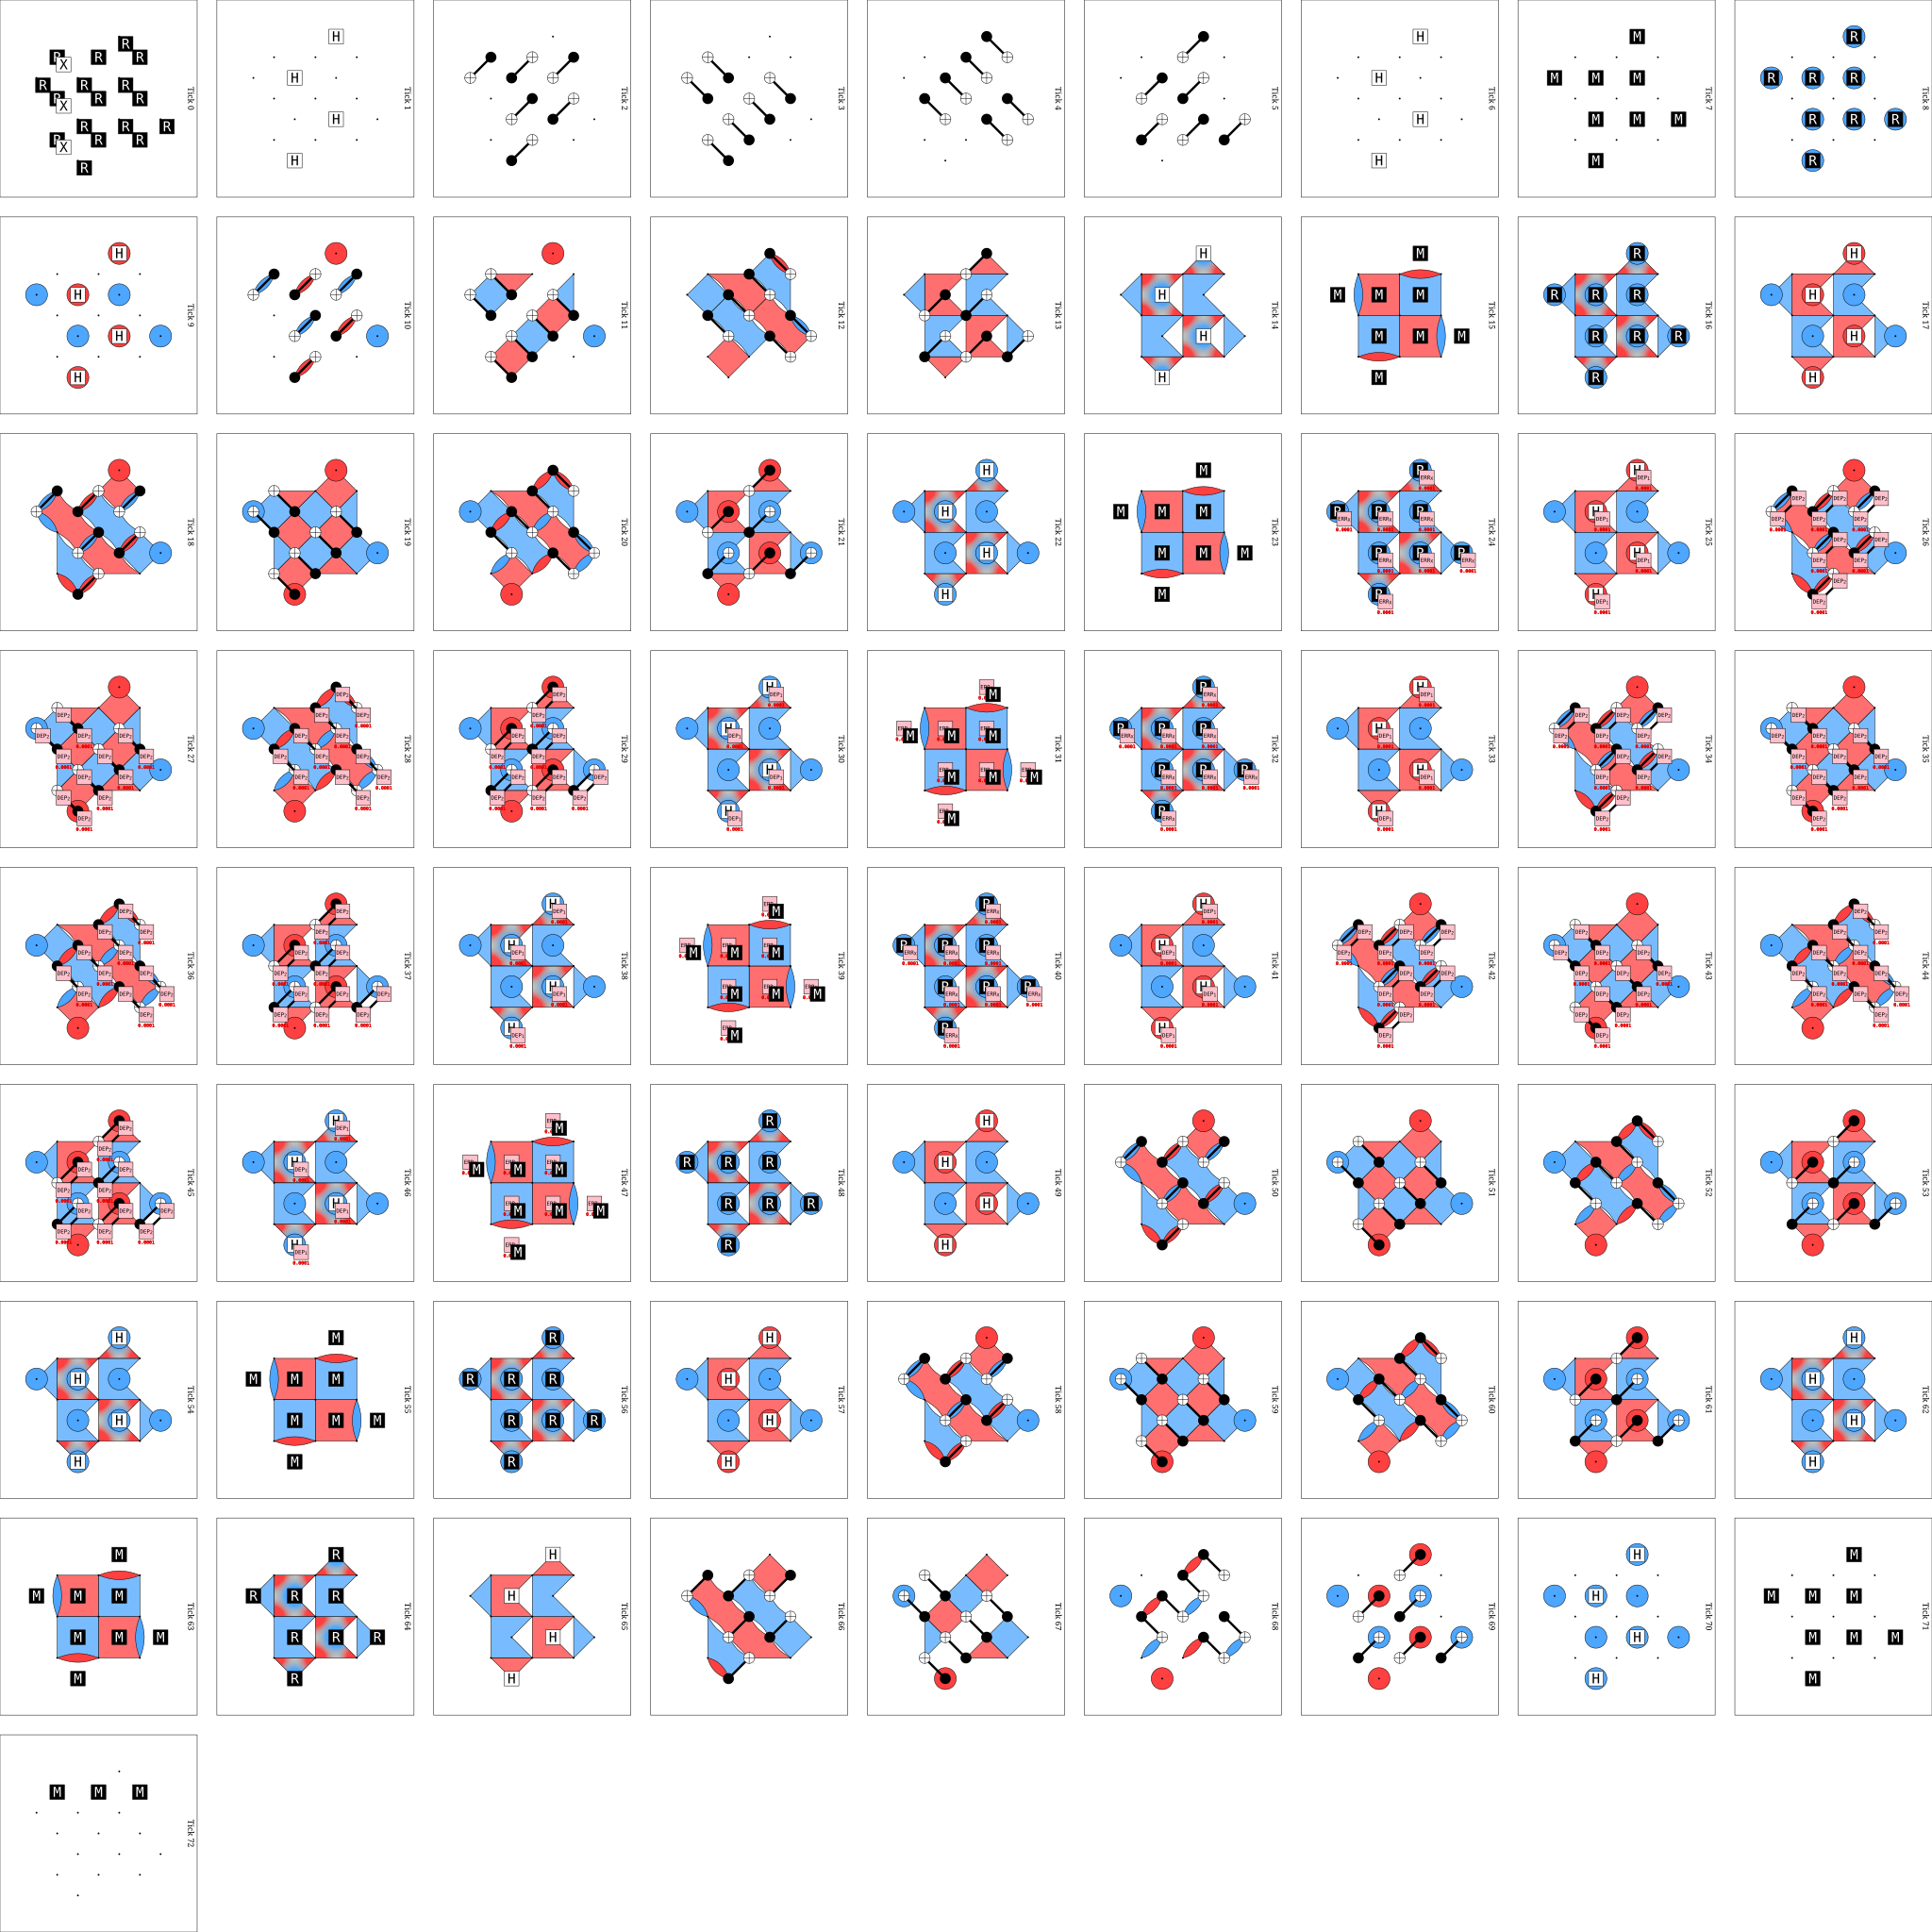

In [19]:
noise = 1e-4

noise_class_circuit = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              before_round_depol=noise)

build = SurfaceBuilder(distance=3, state_init="I1", log_obs="Z", noise=noise_class_circuit)

circuit = build.build_circuit()

circuit.diagram("detslice-with-ops-svg")

In [18]:
# Get Threshold
import itertools
from tqdm import tqdm
import sinter
import math
import os

# geomspace replacement
geom = [10**(math.log10(1e-5) + i*(math.log10(1e-3) - math.log10(1e-5))/9) for i in range(10)]

# linspace replacement
lin = [1.1e-3 + i*(0.015 - 1.1e-3)/39 for i in range(40)]

p_values = geom + lin

distances = [3, 5, 7]

combinations = list(itertools.product(distances, p_values))

# 3. Build the tasks with a progress bar
tasks = [
    sinter.Task(
        circuit= SurfaceBuilder(
            distance= d, 
            state_init="0", 
            log_obs="Z", 
            noise= NoiseParameters(
                before_m_flip_prob=noise,
                after_r_flip=noise,
                after_c_depol_prob=noise,
                before_round_depol=noise
            )
        ).build_circuit(),
        json_metadata={'d': d, 'p': noise},
    )
    for d, noise in tqdm(combinations, desc="Building Circuits")
]

# 4. Now hand them off to sinter
collected_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=10_000,
    print_progress=True
)

Building Circuits:   0%|          | 0/150 [00:00<?, ?it/s]

Building Circuits: 100%|██████████| 150/150 [00:21<00:00,  6.95it/s]
Starting 64 workers...
150 tasks left:
  workers    decoder eta shots_left errors_left json_metadata               
        1 pymatching   ?    1000000       10000 d=3,p=1e-05                 
        1 pymatching   ?    1000000       10000 d=3,p=1.6681005372000593e-05
        1 pymatching <1m     975151       10000 d=3,p=2.782559402207126e-05 
        1 pymatching   ?    1000000       10000 d=3,p=4.641588833612782e-05 
        1 pymatching   ?    1000000       10000 d=3,p=7.742636826811278e-05 
        1 pymatching   ?    1000000       10000 d=3,p=0.0001291549665014884 
        1 pymatching   ?    1000000       10000 d=3,p=0.00021544346900318823
        1 pymatching   ?    1000000       10000 d=3,p=0.00035938136638046257
        1 pymatching   ?    1000000       10000 d=3,p=0.0005994842503189409 
        1 pymatching   ?    1000000       10000 d=3,p=0.001                 
        1 pymatching   ?    1000000       100

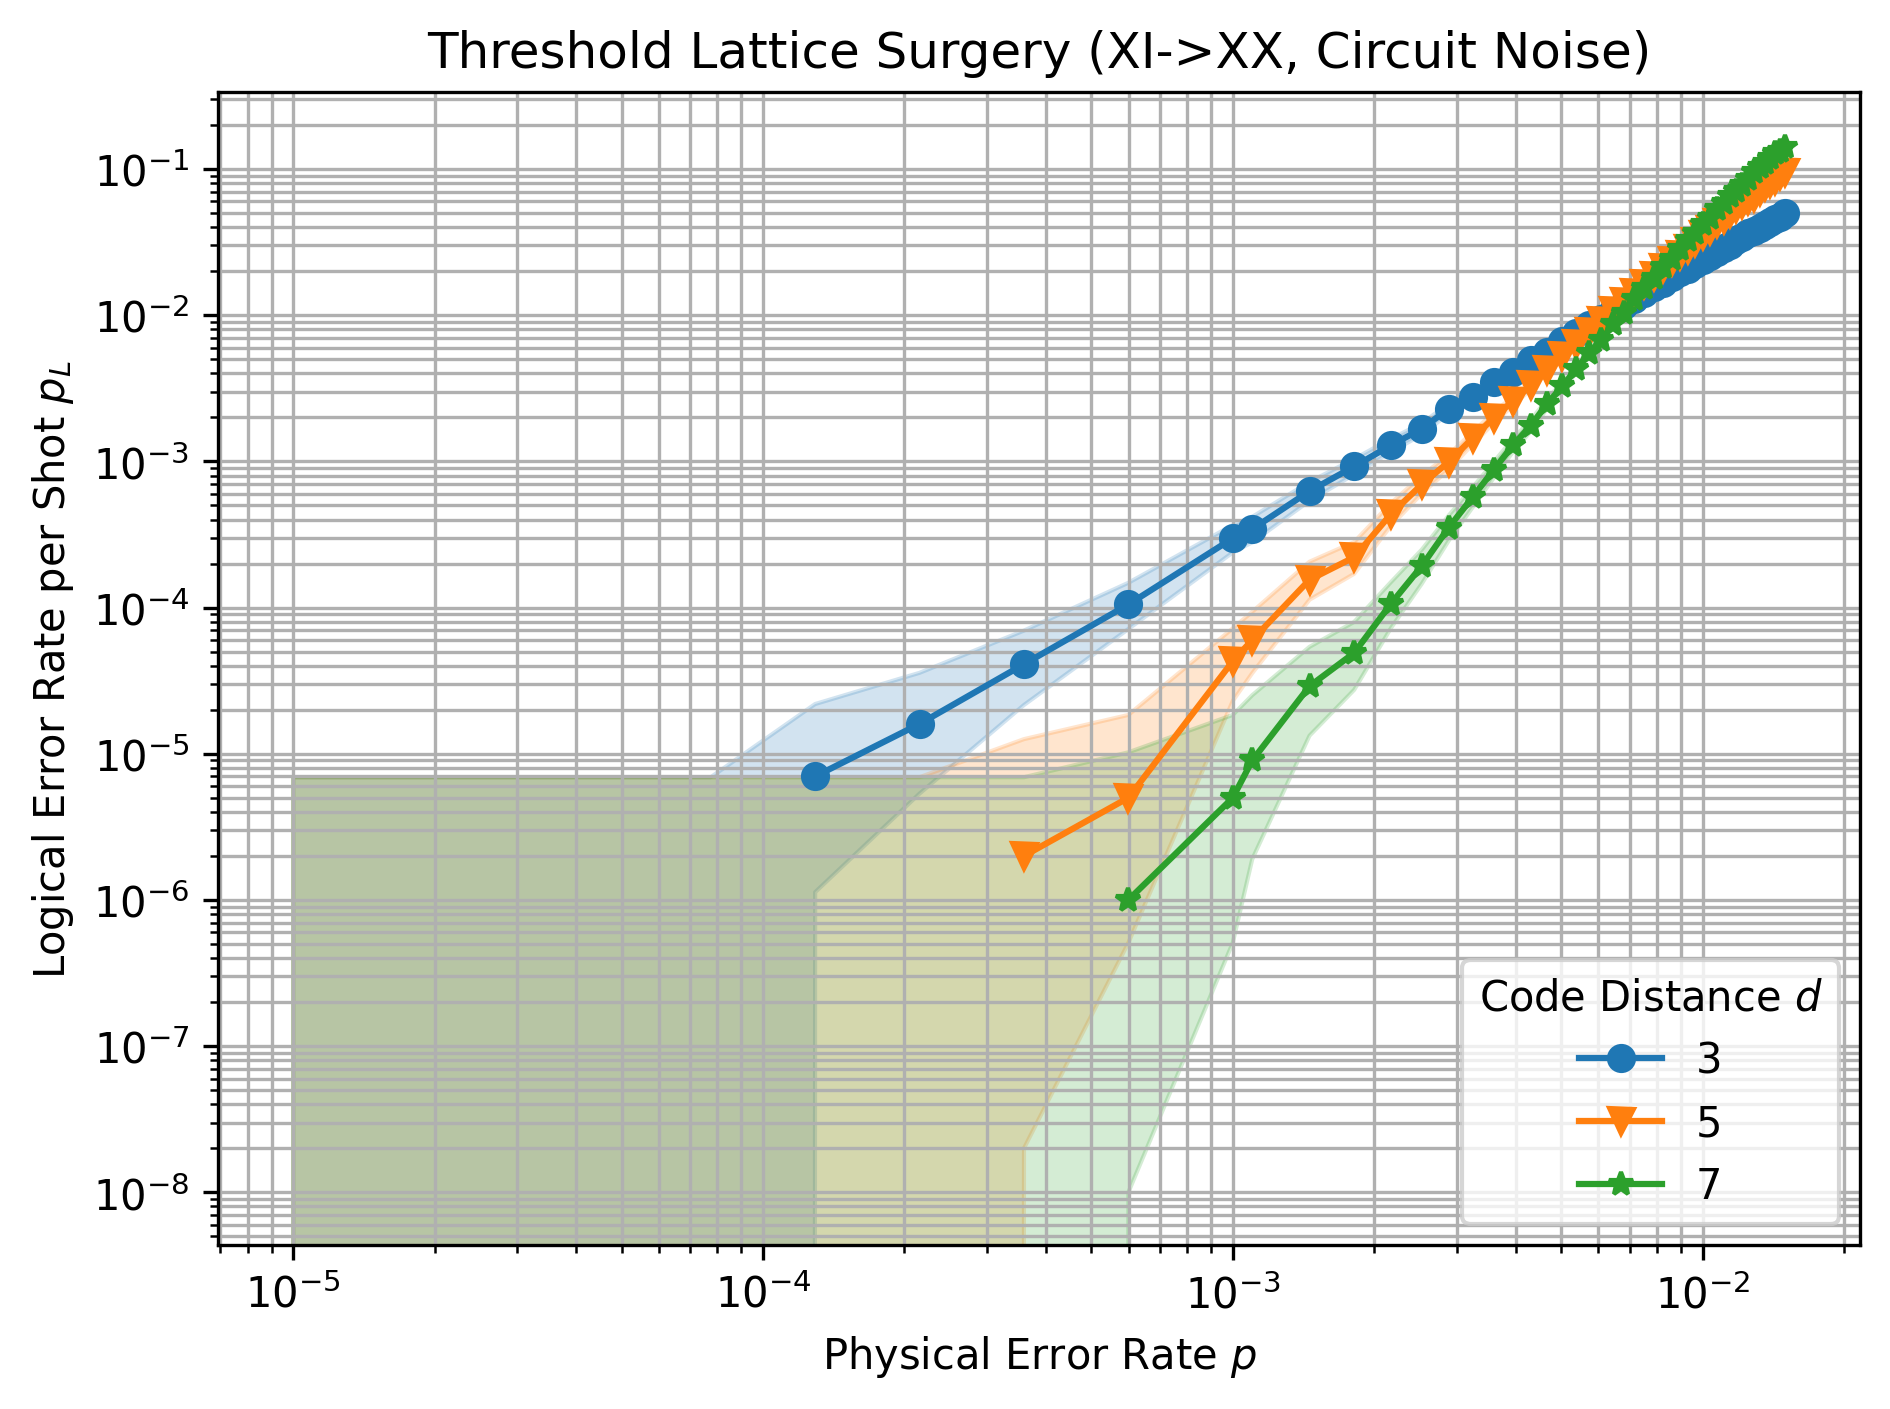

In [19]:
from matplotlib import pyplot as plt

############################################
# Main Plot: Error Rates (Phenomenological)
############################################

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d']
)

# Style main axes
ax.loglog()
ax.set_title("Threshold Lattice Surgery (XI->XX, Circuit Noise)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $p_L$")
ax.grid(which='major')
ax.grid(which='minor')

# Legend in the bottom right
ax.legend(title="Code Distance $d$", loc='lower right')

# Final figure settings
fig.set_dpi(300)
plt.tight_layout()

# Show the plot
plt.show()

In [5]:
from src.codes.lattice_surgery.builder import SurgeryBuilder

**TODO**

- Current Y Observables do not seem to cahnge the measurement outcome when flipped which makes no sense
    - Happens for fault tolerant as well as non fualt tolerant procedure
- Implmented resets on all qubits in non-ft mode but thats total bullshit, makes no sense

In [7]:
noise = 1e-4

noise_class_bias = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_pauli_channel_prob=noise,
                              noise_bias=[0.1, 0.1, 0.8])

noise_class_circuit = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              before_round_depol=noise)


test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="Y-", target_state_init="X+",
                                      control_measure_basis="Y", target_measure_basis="I", noise= noise_class_circuit)

test_surgery_circuit = test_surgery_builder.build_circuit()

# test_surgery_circuit.diagram("detslice-with-ops-svg")